✓ Arquivo ZIP descompactado com sucesso!
Dataset carregado com o formato: (20000, 18)



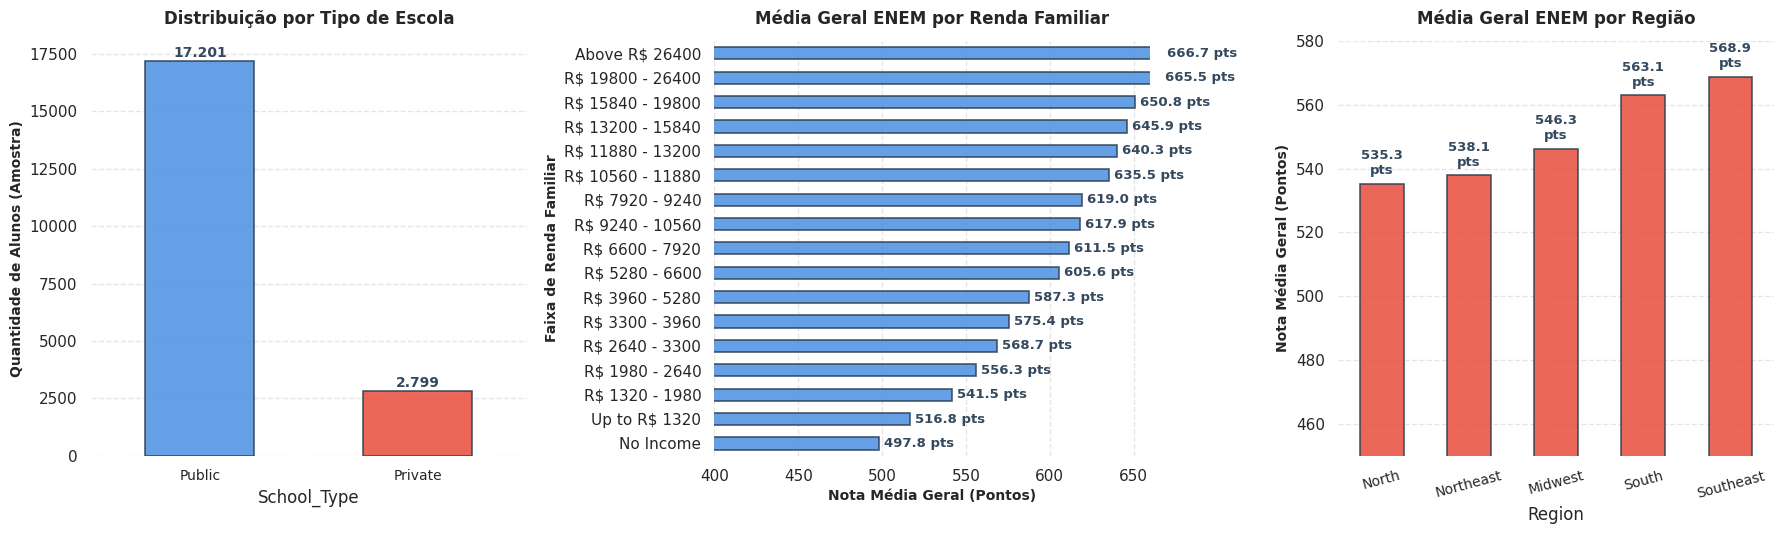

=== ETAPA DE OTIMIZAÇÃO DE HIPERPARÂMETROS ===
Melhor K para KNN encontrado: 21 (Acurácia: 0.4542)


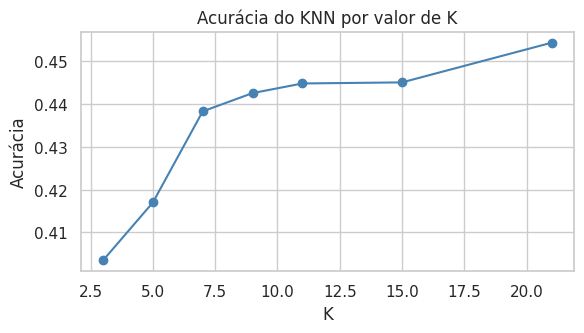

Melhor Profundidade para Árvore encontrada: 5 (Acurácia: 0.4933)
Melhor nº de árvores para Random Forest encontrado: 50 (Acurácia: 0.4620)



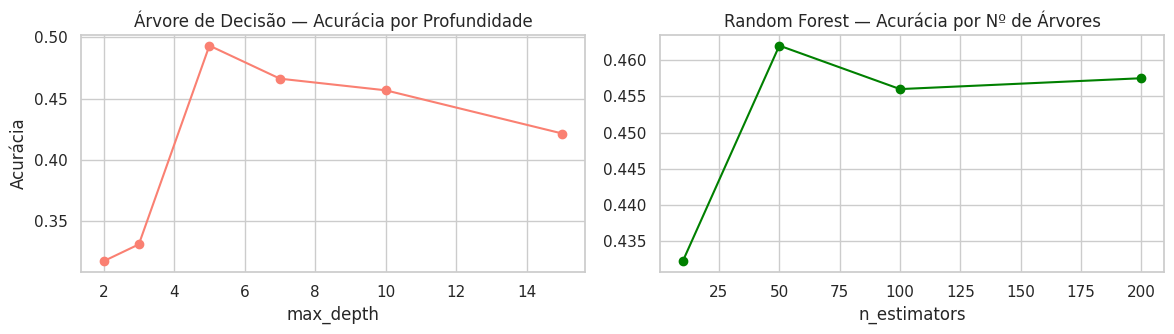

Iniciando o experimento científico definitivo (30 rodadas)...
✓ 30 Execuções concluídas com sucesso!

=== TABLE 1: RESUMO DAS METRICAS APÓS 30 EXECUÇÕES ===
        Algoritmo  Média Acurácia  Desvio-Padrão Acurácia  Mediana Acurácia  Média Macro F1  Mediana Macro F1  Média Tempo (s)  Mediana Tempo (s)
              KNN        0.454050                0.007032          0.453375        0.452579          0.451958         0.555619           0.506418
Árvore de Decisão        0.483242                0.029025          0.488625        0.474860          0.479891         0.017896           0.016301
    Random Forest        0.448233                0.007856          0.449125        0.443948          0.444267         0.540815           0.504484



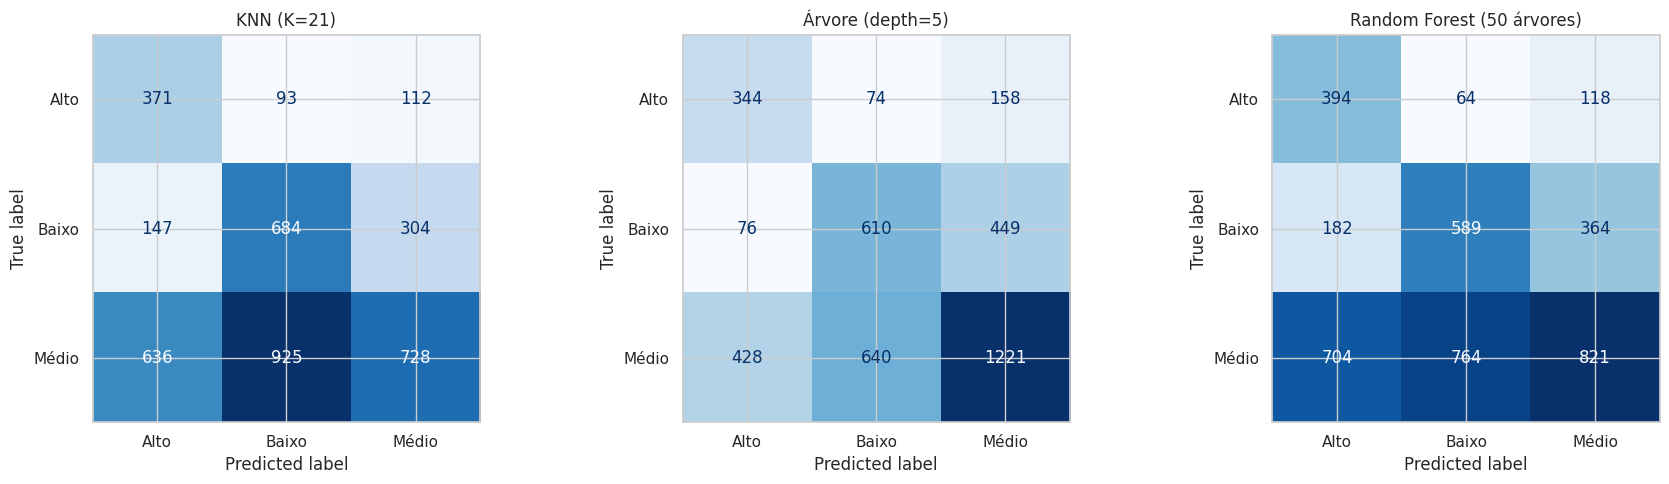

/tmp/ipykernel_2845/1628531480.py:318: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_boxplot, labels=['KNN', 'Árvore de Decisão', 'Random Forest'], patch_artist=True,


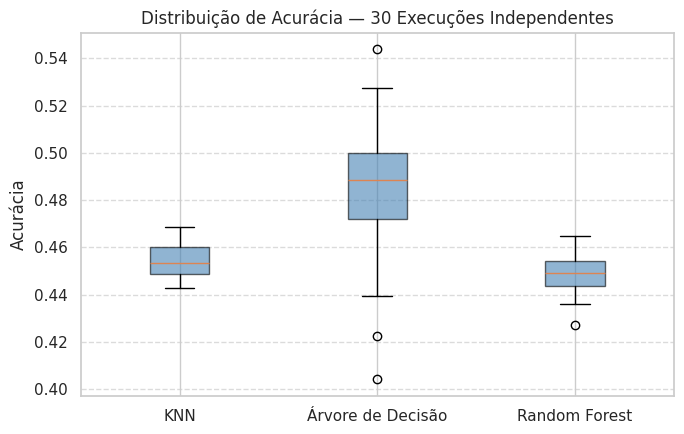

=== ANÁLISE INFERENCIAL ESTÁTISTICA ===
Teste de Kruskal-Wallis: H = 32.9092, p-value = 0.000000
Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre o desempenho dos algoritmos (p < 0.05).


In [2]:
import zipfile
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
from scipy import stats

# 1. DESCOMPACTAÇÃO E CARREGAMENTO DOS DADOS

arquivo_zip = 'microdadosreduzidos.zip'

if os.path.exists(arquivo_zip):
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✓ Arquivo ZIP descompactado com sucesso!")
else:
    print("✗ Erro: O arquivo 'microdadosreduzidos.zip' não foi encontrado.")

# Carregando uma amostra segura de 20.000 linhas (Atende com folga n > 1000)
df = pd.read_csv('ENEM_2023.csv', nrows=20000)
print(f"Dataset carregado com o formato: {df.shape}\n")

# 2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
cor_azul = '#4A90E2'
cor_salmao = '#E74C3C'
cor_borda = '#2C3E50'

# GRÁFICO 1: Tipo de Escola (Distribuição volumétrica da amostra)
contagem_escola = df['School_Type'].value_counts()
contagem_escola.plot(kind='bar', ax=axes[0], color=[cor_azul, cor_salmao], alpha=0.85, edgecolor=cor_borda, linewidth=1.2)

axes[0].set_title('Distribuição por Tipo de Escola', fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Quantidade de Alunos (Amostra)', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for i, v in enumerate(contagem_escola):
    axes[0].text(i, v + (max(contagem_escola) * 0.01), f"{v:,}".replace(',', '.'),
                 ha='center', fontweight='bold', color='#34495E', fontsize=10)

# GRÁFICO 2: Média por Renda Familiar (O SEGREDO: xlim para dar zoom na desigualdade)

ordem_renda = df.groupby('Family_Income')['Mean_Score'].mean().sort_values()
ordem_renda.plot(kind='barh', ax=axes[1], color=cor_azul, alpha=0.85, edgecolor=cor_borda, linewidth=1.2)

axes[1].set_title('Média Geral ENEM por Renda Familiar', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Nota Média Geral (Pontos)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Faixa de Renda Familiar', fontsize=10, fontweight='bold')

axes[1].set_xlim(400, 660)

for i, v in enumerate(ordem_renda):
    axes[1].text(v + 3, i, f"{v:.1f} pts", va='center', fontweight='bold', color='#34495E', fontsize=9.5)

# GRÁFICO 3: Média por Região (O SEGREDO: ylim para mostrar a disparidade regional)
media_regiao = df.groupby('Region')['Mean_Score'].mean().sort_values()
media_regiao.plot(kind='bar', ax=axes[2], color=cor_salmao, alpha=0.85, edgecolor=cor_borda, linewidth=1.2)

axes[2].set_title('Média Geral ENEM por Região', fontsize=12, fontweight='bold', pad=12)
axes[2].set_ylabel('Nota Média Geral (Pontos)', fontsize=10, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15, labelsize=10)


axes[2].set_ylim(450, 580)

# Adiciona o valor exato da média em cima de cada barra vertical
for i, v in enumerate(media_regiao):
    axes[2].text(i, v + 2, f"{v:.1f}\npts", ha='center', va='bottom', fontweight='bold', color='#34495E', fontsize=9.5)

sns.despine(left=True, bottom=True)
axes[0].xaxis.grid(False); axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].yaxis.grid(False); axes[1].xaxis.grid(True, linestyle='--', alpha=0.5)
axes[2].xaxis.grid(False); axes[2].yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('exploratorio_profissional.png', dpi=300)
plt.show()

# 3. PRÉ-PROCESSAMENTO E ENCODING CORRETO
# Definindo as variáveis preditoras
socio_cols = [
    'Age', 'Genre', 'Race', 'School_Type', 'State', 'Region',
    'Father_Education', 'Mother_Education', 'Family_Income',
    'Has_Cell_Phone', 'Has_Computer', 'Has_Internet'
]

# Função de discretização da variável alvo
def classificar_performance(nota):
    if nota < 500: return 'Baixo'
    elif nota <= 650: return 'Médio'
    else: return 'Alto'

df['Performance'] = df['Mean_Score'].apply(classificar_performance)

# Removendo dados nulos estritamente nas colunas de interesse
df_model = df[socio_cols + ['Performance']].copy().dropna()

# CORREÇÃO: 'Age' incluída de volta nas categóricas porque contém textos como '26-30'
cat_cols = [
    'Age', 'Genre', 'Race', 'School_Type', 'State', 'Region',
    'Father_Education', 'Mother_Education', 'Family_Income',
    'Has_Cell_Phone', 'Has_Computer', 'Has_Internet'
]

# Encoding mapeado de forma isolada do alvo
df_enc = df_model.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc[socio_cols]
y = df_enc['Performance']

# 4. ETAPA DE TUNING (OTIMIZAÇÃO DE HIPERPARÂMETROS) - ANTES DO LOOP

print("=== ETAPA DE OTIMIZAÇÃO DE HIPERPARÂMETROS ===")
# Separação inicial de validação para o Tuning (Semente fixa 42)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Correção de Data Leakage: Balanceamento aplicado EXCLUSIVAMENTE no treino
train_temp = pd.concat([X_train_t, y_train_t], axis=1)
df_b = train_temp[train_temp['Performance'] == 'Baixo']
df_m = train_temp[train_temp['Performance'] == 'Médio']
df_a = train_temp[train_temp['Performance'] == 'Alto']
n_target = len(df_a)

train_bal = pd.concat([
    resample(df_b, n_samples=n_target, random_state=42),
    resample(df_m, n_samples=n_target, random_state=42),
    df_a
])
X_train_t_bal = train_bal[socio_cols]
y_train_t_bal = train_bal['Performance']

# Normalização funcionará perfeitamente agora que 'Age' foi codificada em número
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t_bal)
X_test_t_sc = scaler_t.transform(X_test_t)

# --- Otimização KNN ---
k_values = [3, 5, 7, 9, 11, 15, 21]
knn_accs = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_t_sc, y_train_t_bal)
    knn_accs.append(accuracy_score(y_test_t, knn.predict(X_test_t_sc)))

best_k = k_values[np.argmax(knn_accs)]
print(f"Melhor K para KNN encontrado: {best_k} (Acurácia: {max(knn_accs):.4f})")

# Plot do Tuning KNN
plt.figure(figsize=(6, 3.5))
plt.plot(k_values, knn_accs, marker='o', color='steelblue')
plt.title('Acurácia do KNN por valor de K')
plt.xlabel('K')
plt.ylabel('Acurácia')
plt.grid(True)
plt.tight_layout()
plt.savefig('knn_params.png', dpi=150)
plt.show()

# --- Otimização Árvore de Decisão ---
depths = [2, 3, 5, 7, 10, 15]
dt_accs = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_t_bal, y_train_t_bal)
    dt_accs.append(accuracy_score(y_test_t, dt.predict(X_test_t)))

best_depth = depths[np.argmax(dt_accs)]
print(f"Melhor Profundidade para Árvore encontrada: {best_depth} (Acurácia: {max(dt_accs):.4f})")

# --- Otimização Random Forest ---
n_trees = [10, 50, 100, 200]
rf_accs = []
for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_t_bal, y_train_t_bal)
    rf_accs.append(accuracy_score(y_test_t, rf.predict(X_test_t)))

best_n_trees = n_trees[np.argmax(rf_accs)]
print(f"Melhor nº de árvores para Random Forest encontrado: {best_n_trees} (Acurácia: {max(rf_accs):.4f})\n")

# Plot comparativo de parâmetros (Árvore vs RF)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(depths, dt_accs, marker='o', color='salmon')
axes[0].set_title('Árvore de Decisão — Acurácia por Profundidade')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Acurácia')
axes[0].grid(True)

axes[1].plot(n_trees, rf_accs, marker='o', color='green')
axes[1].set_title('Random Forest — Acurácia por Nº de Árvores')
axes[1].set_xlabel('n_estimators')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('params.png', dpi=150)
plt.show()


# 5. EXPERIMENTO PRINCIPAL: 30 RODADAS INDEPENDENTES (COM PARÂMETROS OTIMIZADOS)

print("Iniciando o experimento científico definitivo (30 rodadas)...")
sementes = list(range(30))

# Estruturas para armazenar as métricas coletadas
historico_metrics = {'KNN': {'acc': [], 'f1': [], 'tempo': []},
                     'DT':  {'acc': [], 'f1': [], 'tempo': []},
                     'RF':  {'acc': [], 'f1': [], 'tempo': []}}

for seed in sementes:
    # Divisão de treino/teste mantendo a estratificação das classes
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Balanceamento estrito APENAS na partição de treino corrente (Evita Leakage)
    loop_train_temp = pd.concat([X_train, y_train], axis=1)
    df_loop_b = loop_train_temp[loop_train_temp['Performance'] == 'Baixo']
    df_loop_m = loop_train_temp[loop_train_temp['Performance'] == 'Médio']
    df_loop_a = loop_train_temp[loop_train_temp['Performance'] == 'Alto']
    n_loop_target = len(df_loop_a)

    loop_train_bal = pd.concat([
        resample(df_loop_b, n_samples=n_loop_target, random_state=seed),
        resample(df_loop_m, n_samples=n_loop_target, random_state=seed),
        df_loop_a
    ])
    X_train_bal = loop_train_bal[socio_cols]
    y_train_bal = loop_train_bal['Performance']

    # Escalonamento dos dados do loop corrente
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_bal)
    X_test_sc = scaler.transform(X_test)

    # --- KNN Avaliação ---
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_sc, y_train_bal)
    preds_knn = knn.predict(X_test_sc)
    historico_metrics['KNN']['tempo'].append(time.time() - t0)
    historico_metrics['KNN']['acc'].append(accuracy_score(y_test, preds_knn))
    historico_metrics['KNN']['f1'].append(f1_score(y_test, preds_knn, average='macro'))

    # --- Árvore de Decisão Avaliação ---
    t0 = time.time()
    dt = DecisionTreeClassifier(max_depth=best_depth, random_state=seed)
    dt.fit(X_train_bal, y_train_bal)
    preds_dt = dt.predict(X_test)
    historico_metrics['DT']['tempo'].append(time.time() - t0)
    historico_metrics['DT']['acc'].append(accuracy_score(y_test, preds_dt))
    historico_metrics['DT']['f1'].append(f1_score(y_test, preds_dt, average='macro'))

    # --- Random Forest Avaliação ---
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=best_n_trees, random_state=seed)
    rf.fit(X_train_bal, y_train_bal)
    preds_rf = rf.predict(X_test)
    historico_metrics['RF']['tempo'].append(time.time() - t0)
    historico_metrics['RF']['acc'].append(accuracy_score(y_test, preds_rf))
    historico_metrics['RF']['f1'].append(f1_score(y_test, preds_rf, average='macro'))

print("✓ 30 Execuções concluídas com sucesso!\n")


# 6. EXIBIÇÃO DA TABELA DE ESTATÍSTICAS (EXIGÊNCIA DE MÉDIA, DESVIO-PADRÃO E MEDIANA)

# Mapeamento para construção do DataFrame estatístico final
linhas_tabela = []
for nome, chave in [('KNN', 'KNN'), ('Árvore de Decisão', 'DT'), ('Random Forest', 'RF')]:
    linhas_tabela.append({
        'Algoritmo': nome,
        'Média Acurácia': np.mean(historico_metrics[chave]['acc']),
        'Desvio-Padrão Acurácia': np.std(historico_metrics[chave]['acc']),
        'Mediana Acurácia': np.median(historico_metrics[chave]['acc']),
        'Média Macro F1': np.mean(historico_metrics[chave]['f1']),
        'Mediana Macro F1': np.median(historico_metrics[chave]['f1']),
        'Média Tempo (s)': np.mean(historico_metrics[chave]['tempo']),
        'Mediana Tempo (s)': np.median(historico_metrics[chave]['tempo'])
    })

df_estatisticas = pd.DataFrame(linhas_tabela)
print("=== TABLE 1: RESUMO DAS METRICAS APÓS 30 EXECUÇÕES ===")
print(df_estatisticas.to_string(index=False))
print("======================================================\n")


# 7. MATRIZES DE CONFUSÃO E BOXPLOT COMPARATIVO

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_ordem = ['Alto', 'Baixo', 'Médio']

for ax, pred_vals, titulo in zip(axes, [preds_knn, preds_dt, preds_rf],
                                  [f'KNN (K={best_k})', f'Árvore (depth={best_depth})', f'Random Forest ({best_n_trees} árvores)']):
    ConfusionMatrixDisplay.from_predictions(y_test, pred_vals, display_labels=labels_ordem, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 4.5))
dados_boxplot = [historico_metrics['KNN']['acc'], historico_metrics['DT']['acc'], historico_metrics['RF']['acc']]
plt.boxplot(dados_boxplot, labels=['KNN', 'Árvore de Decisão', 'Random Forest'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Distribuição de Acurácia — 30 Execuções Independentes')
plt.ylabel('Acurácia')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('boxplot_30exec.png', dpi=150)
plt.show()


# 8. TESTE DE HIPÓTESE ESTATÍSTICA (KRUSKAL-WALLIS)

stat, p_value = stats.kruskal(historico_metrics['KNN']['acc'],
                              historico_metrics['DT']['acc'],
                              historico_metrics['RF']['acc'])

print(f"=== ANÁLISE INFERENCIAL ESTÁTISTICA ===")
print(f"Teste de Kruskal-Wallis: H = {stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre o desempenho dos algoritmos (p < 0.05).")
else:
    print("Resultado: Não se rejeita H0. Não há evidências de diferença estatisticamente significativa entre os algoritmos (p >= 0.05).")